# 02 — Classical machine-learning pipeline

Reinhard colour normalization → watershed + geodesic active-contour segmentation → 210
handcrafted features (shape, colour, texture, HOG, Fourier) → feature selection + PCA
(151 features) → 6 classifiers (LightGBM, Random Forest, Extra Trees, RBF-SVM, soft Voting,
Stacking) compared under 5-fold stratified cross-validation.

All the logic lives in `src/segmentation.py`, `src/features.py` and
`src/classical_pipeline.py`; this notebook only calls those functions.

**Execution.** The notebook was run end to end (about 10 hours on 4 shared CPU cores, the
Stacking ensemble alone taking about 4.5 h). Its scores match those saved in
`results/classical_ml/`, which were exported by an earlier scripted run of the same functions
(log in `run.log`); this notebook does not rewrite those result files (it only rebuilds the
feature caches, which are not versioned).

**Class balancing.** Inside each training fold, SMOTE (k = 3) raises every class below 2,000
images to 2,000 (`SMOTE_CAP`), instead of up to the majority class (13,015 SNE images), which
keeps folds at about 39k rows and the SVM-based models tractable.

**Limitation.** The variance/correlation filters, the scaler and the PCA are fitted on the full
training set before cross-validation, so the CV scores are slightly optimistic.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
from src.segmentation import compute_reference_stats
from src.classical_pipeline import (
    extract_features_parallel, prepare_features, compute_lightgbm_importance,
    build_classifiers, run_cv_evaluation, analyze_best_model, BEST_LGBM_PARAMS,
)

DATA = Path("..") / "data"
RESULTS = Path("..") / "results" / "classical_ml"

train_df = pd.read_csv(DATA / "train_metadata.csv")
test_df = pd.read_csv(DATA / "test_metadata.csv")
print(f"train={len(train_df)} test={len(test_df)}")

train=28901 test=9634


In [2]:
ref_mean, ref_std = compute_reference_stats(train_df, DATA / "train")
print(f"Reinhard reference LAB mean={ref_mean}, std={ref_std}")

train_feat_df, test_feat_df = extract_features_parallel(
    train_df, test_df, DATA / "train", DATA / "test", ref_mean, ref_std,
    features_dir=RESULTS, n_jobs=4)

Reinhard reference LAB mean=(np.float64(190.09459313212426), np.float64(138.59816673544574), np.float64(132.7733639430488)), std=(np.float64(22.18844217941521), np.float64(4.253260785806501), np.float64(3.237541374544608))
Extracting TRAIN features (with HOG + Fourier)...


Train features: (28901, 212)

Extracting TEST features (with HOG + Fourier)...


Test features: (9634, 211)


Features saved!


In [3]:
prep = prepare_features(train_feat_df, test_feat_df, plot=False)
X_sel, X_test_sel, y, le = prep['X_sel'], prep['X_test_sel'], prep['y'], prep['le']
combined_feature_names = prep['combined_feature_names']

Initial number of features: 210
Classes: ['BA' 'BL' 'BNE' 'EO' 'LY' 'MMY' 'MO' 'MY' 'PC' 'PLY' 'PMY' 'SNE' 'VLY']
After removing near-zero variance: 210 features
After removing correlated features (>0.95): 131 features


PCA: 20 components, explained variance = 0.787
Final feature set: 151 features (raw + PCA)

Computing feature importances...


## LightGBM feature importance

LightGBM with the tuned hyperparameters, fitted on the full training set; split-count
importance of the 30 most used features (also shown in the report).

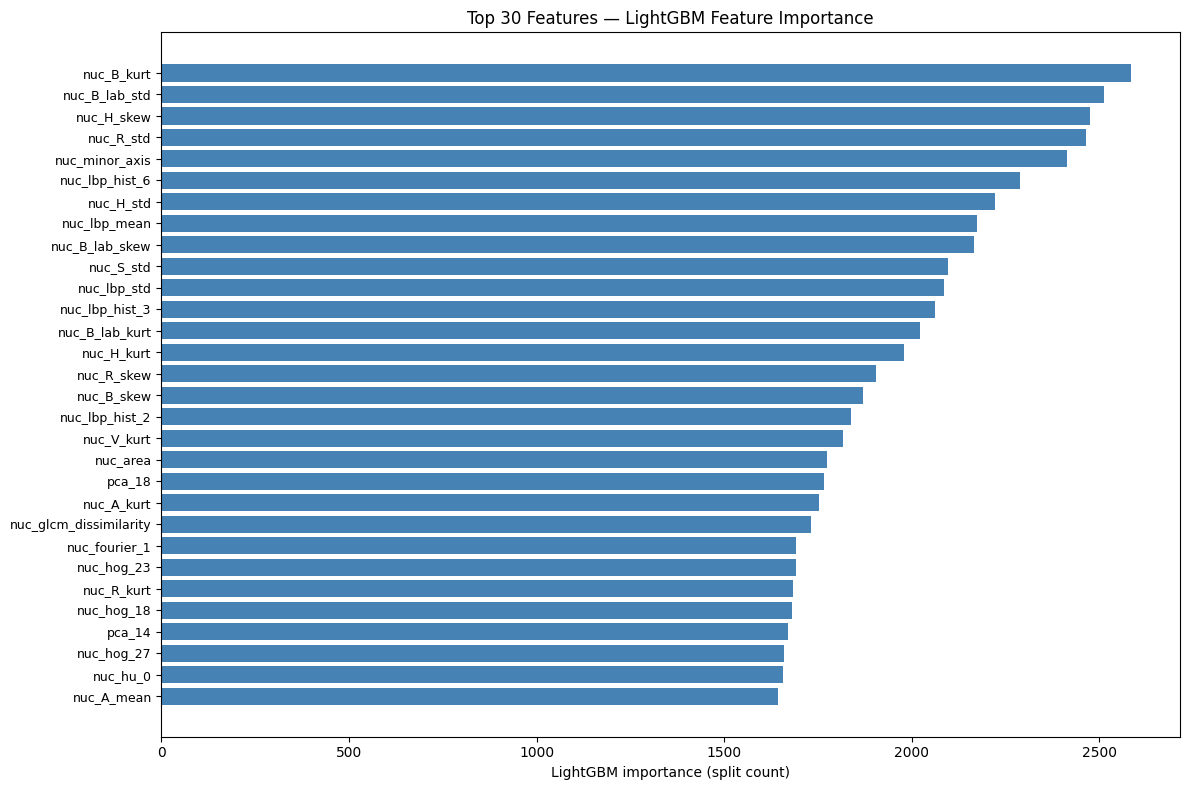

nuc_B_kurt: 2586
nuc_B_lab_std: 2513
nuc_H_skew: 2476
nuc_R_std: 2466
nuc_minor_axis: 2414
nuc_lbp_hist_6: 2289
nuc_H_std: 2221
nuc_lbp_mean: 2174
nuc_B_lab_skew: 2166
nuc_S_std: 2098


In [4]:
lgbm_model, importances, top_idx = compute_lightgbm_importance(
    X_sel, y, combined_feature_names, top_n=30, plot=True)

top10 = sorted(zip([combined_feature_names[i] for i in top_idx], importances[top_idx]),
               key=lambda x: -x[1])[:10]
for name, val in top10:
    print(f"{name}: {val:.0f}")

## 6-classifier comparison, 5-fold CV (SMOTE capped at 2,000 images per class)

Wall-clock times are shown in the log; the Stacking ensemble (nested 5-fold CV of 4 base
learners including the RBF-SVM) takes about 4.5 h.

In [5]:
models = build_classifiers(BEST_LGBM_PARAMS)
results, skf = run_cv_evaluation(models, X_sel, y, n_splits=5, random_state=42)


Model: LightGBM_tuned


  Fold 1: macro-F1 = 0.5112


  Fold 2: macro-F1 = 0.5059


  Fold 3: macro-F1 = 0.5013


  Fold 4: macro-F1 = 0.5508


...

  Fold 1: macro-F1 = 0.4664


  Fold 2: macro-F1 = 0.4411


  Fold 3: macro-F1 = 0.4812


  Fold 4: macro-F1 = 0.4738


  Fold 5: macro-F1 = 0.4345
  → Mean: 0.4594 +/- 0.0184

MODEL SUMMARY (macro-F1)
  LightGBM_tuned      : 0.5089 +/- 0.0244
  Voting              : 0.4963 +/- 0.0142
  RF                  : 0.4773 +/- 0.0177
  Stacking            : 0.4594 +/- 0.0184
  SVM_RBF             : 0.4439 +/- 0.0084
  ExtraTrees          : 0.4344 +/- 0.0142


Best model: LightGBM_tuned (macro-F1 = 0.5089)



Classification Report (OOF)
              precision    recall  f1-score   support

          BA       0.75      0.76      0.76       415
          BL       0.73      0.75      0.74      2012
         BNE       0.16      0.10      0.13       391
          EO       0.84      0.76      0.80       861
          LY       0.85      0.88      0.86      8101
         MMY       0.24      0.14      0.17       360
          MO       0.70      0.81      0.75      2746
          MY       0.38      0.27      0.32       441
          PC       0.52      0.37      0.43        68
         PLY       0.25      0.18      0.21        11
         PMY       0.28      0.17      0.21       114
         SNE       0.91      0.91      0.91     13015
         VLY       0.47      0.25      0.33       366

    accuracy                           0.83     28901
   macro avg       0.54      0.49      0.51     28901
weighted avg       0.82      0.83      0.83     28901



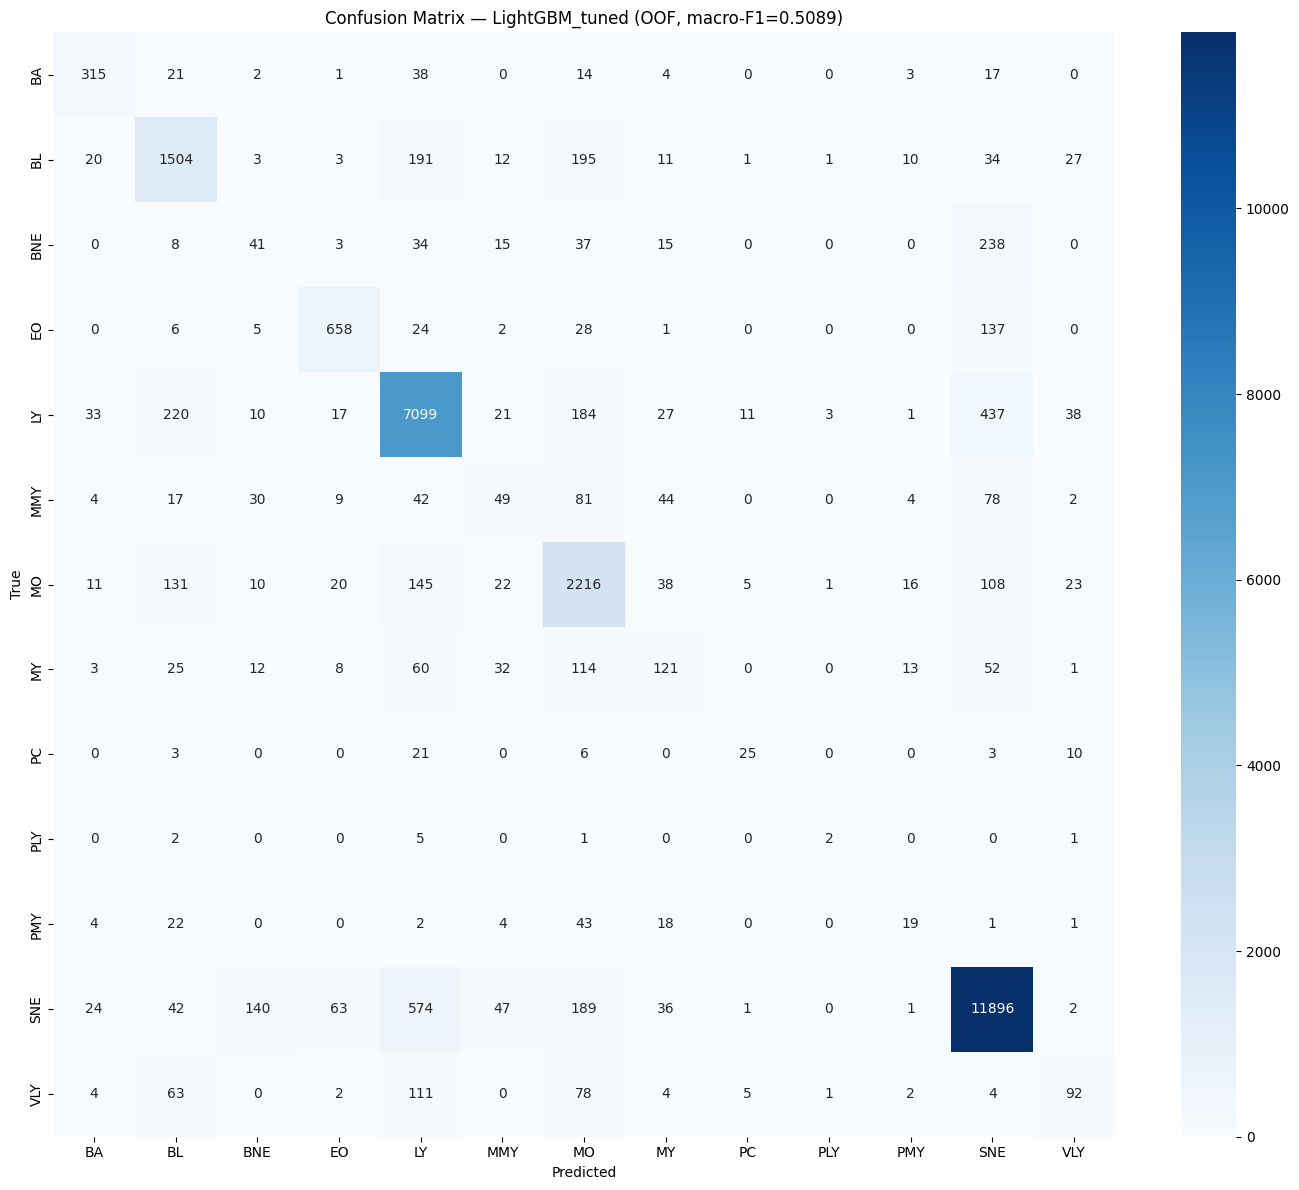

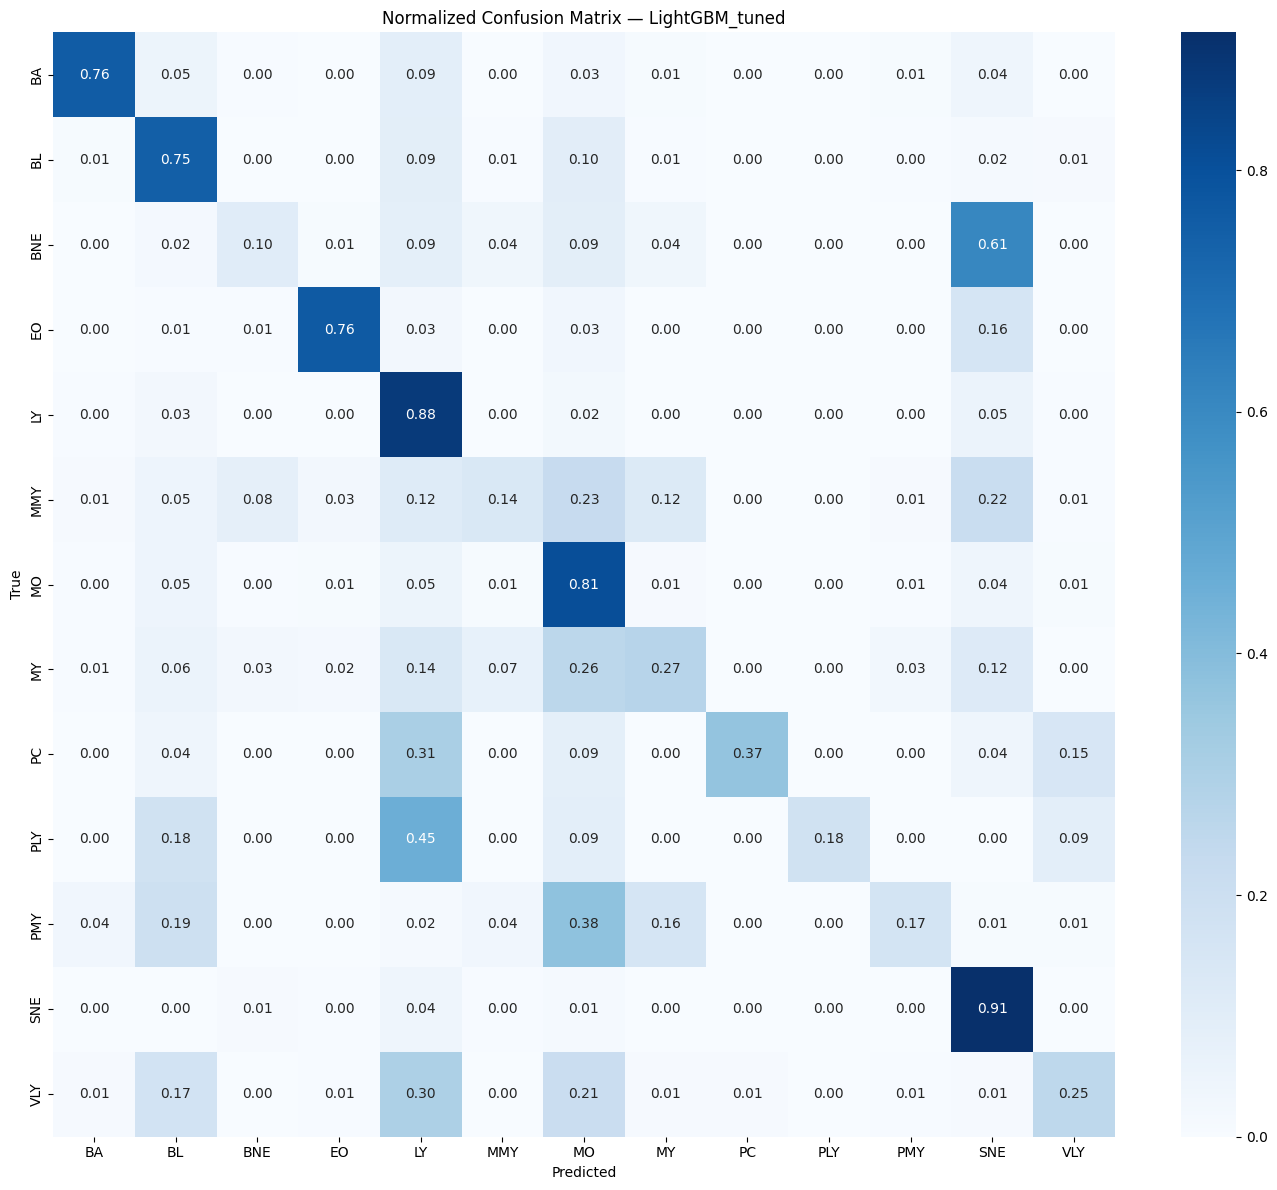


Per-class F1 scores:
  BA   (n=  415): F1 = 0.7563
  BL   (n= 2012): F1 = 0.7380
  BNE  (n=  391): F1 = 0.1273
  EO   (n=  861): F1 = 0.8000
  LY   (n= 8101): F1 = 0.8633
  MMY  (n=  360): F1 = 0.1738
  MO   (n= 2746): F1 = 0.7471
  MY   (n=  441): F1 = 0.3184
  PC   (n=   68): F1 = 0.4310
  PLY  (n=   11): F1 = 0.2105
  PMY  (n=  114): F1 = 0.2077
  SNE  (n=13015): F1 = 0.9144
  VLY  (n=  366): F1 = 0.3268


In [6]:
best_name, oof_preds = analyze_best_model(models, results, skf, X_sel, y, le, plot=True)

## Summary

| Model | Macro-F1 (5-fold CV) |
|---|---|
| LightGBM_tuned | 0.5089 ± 0.0244 |
| Voting | 0.4963 ± 0.0142 |
| RF | 0.4773 ± 0.0177 |
| Stacking | 0.4594 ± 0.0184 |
| SVM_RBF | 0.4439 ± 0.0084 |
| ExtraTrees | 0.4344 ± 0.0142 |

**Best: LightGBM_tuned, macro-F1 = 0.5089 ± 0.0244, OOF accuracy = 0.8317**

Raw numbers backing this notebook: `results/classical_ml/summary.json`, `cv_results.json`,
`classification_report.json`, `confusion_matrix.npy`, `feature_importance_lightgbm.csv`.